# 3.1 — Análise e diagnóstico dos resultados SHAP

Este notebook **consome** o consolidado produzido em `3.1_shap_baselines.ipynb` e responde, de forma automatizada, três perguntas:

1. **Os modelos concordam** sobre quais features são importantes? (estabilidade de ranking)
2. **Qual o cutoff Top-k** que pode ser justificado a partir dos dados? (cobertura de importância)
3. **Como isso impacta** as etapas downstream (3.2 — modelos reduzidos, 4 — otimização, 5 — comparação com REF1)?

Insumos:
- `ARTEFATOS/ETAPA_3/shap/3.1_shap_consolidado.csv` (saída de `3.1_shap_baselines.ipynb`)
- Convenções e decisões registradas em `REGISTRO.md` (Etapa 3): D-E3-01, D-E3-02

Saída:
- Tabelas e figuras de diagnóstico salvas em `ARTEFATOS/ETAPA_3/shap/` com prefixo `3.1_diag_`
- Sugestão **automatizada** (não definitiva) de cutoff Top-k, a ser referendada antes da Etapa 3.2

## Seção 1 — Imports e configuração

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, kendalltau

PROJECT_ROOT = Path("/Users/lorenzoferreira/Documents/UFRGS/TCC_SBO")
SHAP_DIR     = PROJECT_ROOT / "ARTEFATOS" / "ETAPA_3" / "3.1_SHAP"
CSV_CONSOL   = SHAP_DIR / "3.1_shap_consolidado.csv"

FEATURE_NAMES = ["P1", "T1", "T2", "RRC1", "BRC1", "RRC2", "BRC2", "RFF"]
MODELS  = ["SVR", "DT", "RF", "XGBoost", "ANN"]
OUTPUTS = ["ET", "M_CH3OH", "x_CH3OH"]

assert CSV_CONSOL.exists(), f"Consolidado não encontrado em {CSV_CONSOL}"

## Seção 2 — Carga do consolidado e visão geral

O consolidado tem schema `(modelo, output, feature, shap_mean, shap_rank)`, totalizando `5 × 3 × 8 = 120` linhas. Aqui validamos a integridade e geramos uma visão geral por output.

In [2]:
df = pd.read_csv(CSV_CONSOL)

# Validações estruturais
assert len(df) == len(MODELS) * len(OUTPUTS) * len(FEATURE_NAMES), \
    f"Esperado {len(MODELS)*len(OUTPUTS)*len(FEATURE_NAMES)} linhas, obtido {len(df)}"
assert set(df["modelo"].unique())   == set(MODELS)
assert set(df["output"].unique())   == set(OUTPUTS)
assert set(df["feature"].unique())  == set(FEATURE_NAMES)

print(f"Linhas: {len(df)}")
print(f"Modelos: {sorted(df['modelo'].unique())}")
print(f"Outputs: {sorted(df['output'].unique())}")
print(f"shap_mean range: [{df['shap_mean'].min():.6f}, {df['shap_mean'].max():.6f}]")

Linhas: 120
Modelos: ['ANN', 'DT', 'RF', 'SVR', 'XGBoost']
Outputs: ['ET', 'M_CH3OH', 'x_CH3OH']
shap_mean range: [0.000189, 0.124837]


In [3]:
# Tabela média (entre modelos) de shap_mean por output × feature.
# Útil como visão de "importância consensual".
pivot_mean = (
    df.groupby(["output", "feature"])["shap_mean"]
      .mean()
      .unstack("feature")
      .reindex(index=OUTPUTS, columns=FEATURE_NAMES)
)
print("SHAP médio entre os 5 modelos (linhas = output, colunas = feature):\n")
print(pivot_mean.round(4).to_string())

SHAP médio entre os 5 modelos (linhas = output, colunas = feature):

feature      P1      T1      T2    RRC1    BRC1    RRC2    BRC2     RFF
output                                                                 
ET       0.0027  0.0256  0.0015  0.0069  0.0819  0.0410  0.0067  0.0959
M_CH3OH  0.0093  0.0801  0.0019  0.0792  0.0818  0.0312  0.0392  0.0847
x_CH3OH  0.0026  0.0099  0.0019  0.1202  0.0632  0.0321  0.0259  0.0057


## Seção 3 — Estabilidade de ranking entre modelos

**Pergunta:** os 5 modelos atribuem ranks coerentes às 8 features, output a output?

**Procedimento:** para cada output, calcular a correlação de Spearman entre os vetores de rank de todos os pares de modelos. Se a estabilidade for alta (ρ médio ≥ 0.9), a decisão de Top-k pode ser tomada com qualquer modelo de referência; se baixa, a escolha do modelo importa.

**Por que ranks e não SHAP médio absoluto?** Os valores SHAP têm escalas distintas entre modelos (em especial entre ANN/XGBoost e SVR), mas a ordem relativa entre features é a informação direta para feature selection.

In [4]:
def pairwise_rank_corr(df_output: pd.DataFrame, method: str = "spearman") -> pd.DataFrame:
    """Matriz de correlação de ranks entre pares de modelos para um output fixo."""
    rank_matrix = (
        df_output.pivot(index="feature", columns="modelo", values="shap_rank")
                 .reindex(index=FEATURE_NAMES, columns=MODELS)
    )
    corr = pd.DataFrame(index=MODELS, columns=MODELS, dtype=float)
    for m1 in MODELS:
        for m2 in MODELS:
            if method == "spearman":
                rho, _ = spearmanr(rank_matrix[m1], rank_matrix[m2])
            else:
                rho, _ = kendalltau(rank_matrix[m1], rank_matrix[m2])
            corr.loc[m1, m2] = rho
    return corr

stability_summary = {}
for out in OUTPUTS:
    corr = pairwise_rank_corr(df[df["output"] == out])
    # Média do triângulo superior (exclui diagonal)
    iu = np.triu_indices_from(corr.values, k=1)
    mean_rho = corr.values[iu].mean()
    min_rho  = corr.values[iu].min()
    stability_summary[out] = {"mean_rho": mean_rho, "min_rho": min_rho, "matrix": corr}
    print(f"[{out}] Spearman médio entre modelos = {mean_rho:.3f} | mínimo = {min_rho:.3f}")
    print(corr.round(2).to_string(), "\n")

[ET] Spearman médio entre modelos = 0.986 | mínimo = 0.976
          SVR    DT    RF  XGBoost   ANN
SVR      1.00  0.98  0.98     1.00  1.00
DT       0.98  1.00  1.00     0.98  0.98
RF       0.98  1.00  1.00     0.98  0.98
XGBoost  1.00  0.98  0.98     1.00  1.00
ANN      1.00  0.98  0.98     1.00  1.00 

[M_CH3OH] Spearman médio entre modelos = 0.962 | mínimo = 0.929
          SVR    DT    RF  XGBoost   ANN
SVR      1.00  0.93  0.98     0.93  1.00
DT       0.93  1.00  0.98     1.00  0.93
RF       0.98  0.98  1.00     0.98  0.98
XGBoost  0.93  1.00  0.98     1.00  0.93
ANN      1.00  0.93  0.98     0.93  1.00 

[x_CH3OH] Spearman médio entre modelos = 1.000 | mínimo = 1.000
         SVR   DT   RF  XGBoost  ANN
SVR      1.0  1.0  1.0      1.0  1.0
DT       1.0  1.0  1.0      1.0  1.0
RF       1.0  1.0  1.0      1.0  1.0
XGBoost  1.0  1.0  1.0      1.0  1.0
ANN      1.0  1.0  1.0      1.0  1.0 



In [5]:
# Diagnóstico textual automático sobre estabilidade.
THRESHOLD_STRONG = 0.90
THRESHOLD_MOD    = 0.75

for out, info in stability_summary.items():
    rho = info["mean_rho"]
    if rho >= THRESHOLD_STRONG:
        veredito = "ALTA  — modelos concordam fortemente; Top-k pode ser definido com qualquer modelo de referência"
    elif rho >= THRESHOLD_MOD:
        veredito = "MODERADA — Top-k robusto exige união entre modelos ou referência no ANN (R² mais alto)"
    else:
        veredito = "BAIXA — modelos discordam; escolha do modelo de referência muda o cutoff e deve ser justificada"
    print(f"[{out}] ρ̄ = {rho:.3f} → estabilidade {veredito}")

[ET] ρ̄ = 0.986 → estabilidade ALTA  — modelos concordam fortemente; Top-k pode ser definido com qualquer modelo de referência
[M_CH3OH] ρ̄ = 0.962 → estabilidade ALTA  — modelos concordam fortemente; Top-k pode ser definido com qualquer modelo de referência
[x_CH3OH] ρ̄ = 1.000 → estabilidade ALTA  — modelos concordam fortemente; Top-k pode ser definido com qualquer modelo de referência


## Seção 4 — Cobertura de importância (curva cumulativa)

**Pergunta:** quantas features bastam para cobrir, p.ex., 95% da soma de SHAP médio absoluto? Esse é um critério de cutoff **dependente dos dados** (alternativa ao Top-k arbitrário registrado como Q2).

**Procedimento:** para cada (modelo, output), normalizar `shap_mean` para somar 1 e plotar a curva cumulativa ordenada por rank. Reportar o menor k que atinge thresholds de 90% e 95%.

In [6]:
def k_para_cobertura(shap_means: np.ndarray, threshold: float) -> int:
    """Retorna o menor k tal que a soma dos top-k features cubra >= threshold da massa total."""
    s = np.sort(shap_means)[::-1]
    cum = np.cumsum(s) / s.sum()
    return int(np.searchsorted(cum, threshold) + 1)

rows = []
for modelo in MODELS:
    for out in OUTPUTS:
        sub = df[(df["modelo"] == modelo) & (df["output"] == out)]
        sm = sub["shap_mean"].values
        rows.append({
            "modelo":   modelo,
            "output":   out,
            "k_90":     k_para_cobertura(sm, 0.90),
            "k_95":     k_para_cobertura(sm, 0.95),
            "k_99":     k_para_cobertura(sm, 0.99),
        })
cov_df = pd.DataFrame(rows)
print("k mínimo para atingir threshold de cobertura, por (modelo, output):\n")
print(cov_df.to_string(index=False))

print("\nResumo por output (max entre modelos = pior caso):")
print(cov_df.groupby("output")[["k_90", "k_95", "k_99"]].max().to_string())

k mínimo para atingir threshold de cobertura, por (modelo, output):

 modelo  output  k_90  k_95  k_99
    SVR      ET     4     6     7
    SVR M_CH3OH     6     6     7
    SVR x_CH3OH     5     6     8
     DT      ET     4     5     7
     DT M_CH3OH     5     6     7
     DT x_CH3OH     4     4     6
     RF      ET     4     4     6
     RF M_CH3OH     5     6     7
     RF x_CH3OH     4     4     6
XGBoost      ET     4     5     7
XGBoost M_CH3OH     6     6     7
XGBoost x_CH3OH     4     5     7
    ANN      ET     4     5     7
    ANN M_CH3OH     6     6     7
    ANN x_CH3OH     4     5     7

Resumo por output (max entre modelos = pior caso):
         k_90  k_95  k_99
output                   
ET          4     6     7
M_CH3OH     6     6     7
x_CH3OH     5     6     8


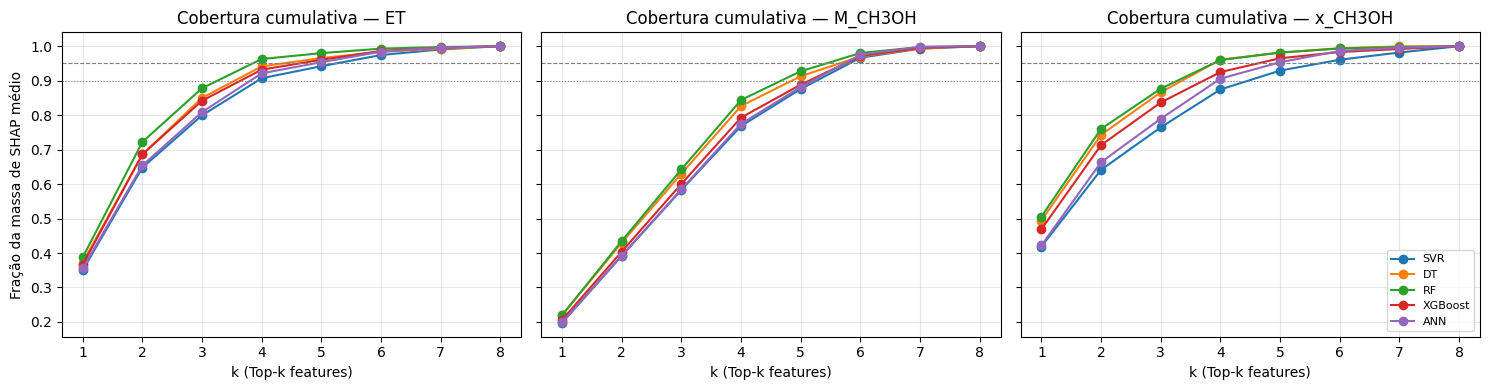

In [7]:
# Curva cumulativa de cobertura por output, sobrepondo os 5 modelos.
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, out in zip(axes, OUTPUTS):
    for modelo in MODELS:
        sub = df[(df["modelo"] == modelo) & (df["output"] == out)]
        s = np.sort(sub["shap_mean"].values)[::-1]
        cum = np.cumsum(s) / s.sum()
        ax.plot(range(1, len(cum) + 1), cum, marker="o", label=modelo)
    ax.axhline(0.90, color="gray", linestyle=":", linewidth=0.8)
    ax.axhline(0.95, color="gray", linestyle="--", linewidth=0.8)
    ax.set_title(f"Cobertura cumulativa — {out}")
    ax.set_xlabel("k (Top-k features)")
    ax.set_xticks(range(1, 9))
    ax.grid(alpha=0.3)
axes[0].set_ylabel("Fração da massa de SHAP médio")
axes[-1].legend(loc="lower right", fontsize=8)
plt.tight_layout()
fig.savefig(SHAP_DIR / "3.1_diag_cobertura.png", dpi=120, bbox_inches="tight")
plt.show()

## Seção 5 — Heatmap de ranks (modelo × feature × output)

Visualização compacta para inspecionar onde os modelos divergem. Cores escuras = rank baixo (mais importante).

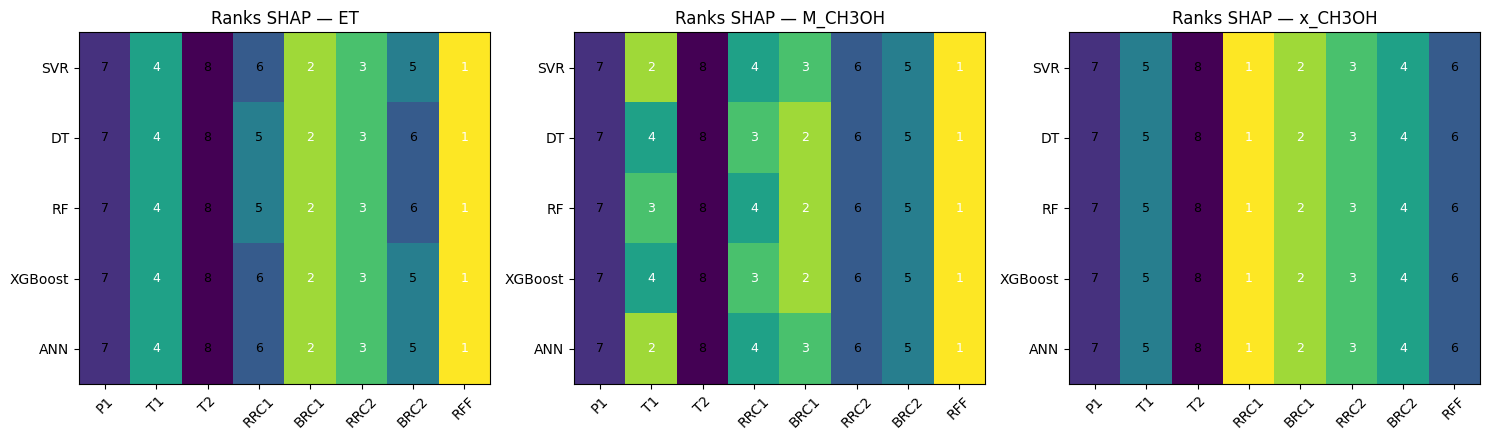

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, out in zip(axes, OUTPUTS):
    sub = df[df["output"] == out]
    rank_matrix = (
        sub.pivot(index="modelo", columns="feature", values="shap_rank")
           .reindex(index=MODELS, columns=FEATURE_NAMES)
    )
    im = ax.imshow(rank_matrix.values, cmap="viridis_r", aspect="auto", vmin=1, vmax=8)
    ax.set_xticks(range(len(FEATURE_NAMES)), FEATURE_NAMES, rotation=45)
    ax.set_yticks(range(len(MODELS)), MODELS)
    ax.set_title(f"Ranks SHAP — {out}")
    for i in range(len(MODELS)):
        for j in range(len(FEATURE_NAMES)):
            ax.text(j, i, int(rank_matrix.values[i, j]),
                    ha="center", va="center",
                    color="white" if rank_matrix.values[i, j] <= 4 else "black",
                    fontsize=9)
plt.tight_layout()
fig.savefig(SHAP_DIR / "3.1_diag_heatmap_ranks.png", dpi=120, bbox_inches="tight")
plt.show()

## Seção 6 — Decisão automática de cutoff Top-k

**Regra adotada (data-driven, agnóstica a modelo):**

1. Para cada `(modelo, output)`, identificar as features que aparecem no Top-k para `k ∈ {4, 5, 6, 7}`.
2. Tomar a **união** entre os 5 modelos × 3 outputs.
3. Reportar o menor k tal que a união resulta em um conjunto compacto e estável (i.e., aumentar k não traz features novas).

Essa regra evita viés de modelo único e é defensável academicamente: "manter qualquer feature que algum modelo, em algum output, considerou relevante".

In [9]:
def top_k_union(df: pd.DataFrame, k: int) -> set:
    """União de features que aparecem no Top-k para algum (modelo, output)."""
    return set(df[df["shap_rank"] <= k]["feature"].unique())

print("Tamanho da união Top-k entre todos modelos × outputs:\n")
uniao_por_k = {}
for k in range(1, 9):
    uniao = top_k_union(df, k)
    uniao_por_k[k] = uniao
    print(f"  k={k}: {len(uniao)} features — {sorted(uniao, key=FEATURE_NAMES.index)}")

# Menor k tal que a união estabiliza (não muda quando k aumenta para k+1).
k_estavel = None
for k in range(1, 8):
    if uniao_por_k[k] == uniao_por_k[k + 1]:
        k_estavel = k
        break

if k_estavel is not None:
    features_mantidas = sorted(uniao_por_k[k_estavel], key=FEATURE_NAMES.index)
    features_descartadas = [f for f in FEATURE_NAMES if f not in features_mantidas]
    print(f"\n→ Cutoff sugerido: Top-{k_estavel}")
    print(f"  União estabiliza em |F| = {len(features_mantidas)} features: {features_mantidas}")
    print(f"  Features descartáveis: {features_descartadas}")
else:
    print("\n→ União não estabiliza dentro de k ∈ [1, 8]; reavaliar critério")

Tamanho da união Top-k entre todos modelos × outputs:

  k=1: 2 features — ['RRC1', 'RFF']
  k=2: 4 features — ['T1', 'RRC1', 'BRC1', 'RFF']
  k=3: 5 features — ['T1', 'RRC1', 'BRC1', 'RRC2', 'RFF']
  k=4: 6 features — ['T1', 'RRC1', 'BRC1', 'RRC2', 'BRC2', 'RFF']
  k=5: 6 features — ['T1', 'RRC1', 'BRC1', 'RRC2', 'BRC2', 'RFF']
  k=6: 6 features — ['T1', 'RRC1', 'BRC1', 'RRC2', 'BRC2', 'RFF']
  k=7: 7 features — ['P1', 'T1', 'RRC1', 'BRC1', 'RRC2', 'BRC2', 'RFF']
  k=8: 8 features — ['P1', 'T1', 'T2', 'RRC1', 'BRC1', 'RRC2', 'BRC2', 'RFF']

→ Cutoff sugerido: Top-4
  União estabiliza em |F| = 6 features: ['T1', 'RRC1', 'BRC1', 'RRC2', 'BRC2', 'RFF']
  Features descartáveis: ['P1', 'T2']


In [10]:
# Verificação cruzada: para as features descartadas, qual a contribuição relativa máxima
# entre todos os (modelo, output)? Idealmente baixa (< 5%).
if k_estavel is not None and features_descartadas:
    df_norm = df.copy()
    df_norm["shap_share"] = df_norm.groupby(["modelo", "output"])["shap_mean"]\
                                   .transform(lambda x: x / x.sum())
    desc = df_norm[df_norm["feature"].isin(features_descartadas)]\
             .groupby("feature")["shap_share"]\
             .agg(["max", "mean"])\
             .round(4)
    print("Contribuição relativa das features descartadas (entre todos modelo × output):")
    print(desc.to_string())
    print("\nInterpretação: 'max' = pior caso (modelo/output em que a feature mais importou).")
    print("Se max < 0.05, descarte é seguro do ponto de vista de SHAP.")

Contribuição relativa das features descartadas (entre todos modelo × output):
            max    mean
feature                
P1       0.0262  0.0142
T2       0.0184  0.0057

Interpretação: 'max' = pior caso (modelo/output em que a feature mais importou).
Se max < 0.05, descarte é seguro do ponto de vista de SHAP.


In [11]:
# Persistir a decisão sugerida em CSV para consumo da Etapa 3.2.
if k_estavel is not None:
    decisao_path = SHAP_DIR / "3.1_diag_cutoff_sugerido.csv"
    pd.DataFrame({
        "feature": FEATURE_NAMES,
        "manter":  [f in features_mantidas for f in FEATURE_NAMES],
        "criterio": f"uniao_top_{k_estavel}_estavel",
    }).to_csv(decisao_path, index=False)
    print(f"Sugestão persistida em: {decisao_path.relative_to(PROJECT_ROOT)}")

Sugestão persistida em: ARTEFATOS/ETAPA_3/shap/3.1_diag_cutoff_sugerido.csv


## Seção 7 — Implicações para etapas downstream

### 7.1 Etapa 3.2 — Modelos reduzidos

A decisão Q2 do PLANO_3 tem dois eixos: **granularidade** (global vs. por output) e **critério de corte** (Top-k fixo, threshold de cobertura, ou união).

- **Granularidade global** (já registrada): um único conjunto de features para os 3 outputs. **Compatível** com a análise acima — a união Top-k é, por construção, global.
- **Critério de corte = Top-k fixo** (registrado): a Seção 6 sugere k automaticamente; a decisão final permanece humana.
- **Risco residual:** features descartadas podem ter contribuições não-lineares que se cancelam em média (SHAP mede contribuição média, não derivada local). Em casos de dúvida, retreinar com e sem cada feature "borderline" e comparar R² é o teste empírico decisivo.

### 7.2 Etapa 4 — Otimização

- Features descartadas (rank 7–8) tendem a estar **fora do espaço de busca útil**: o otimizador as variará mas o efeito sobre os outputs será mínimo.
- **Opção pragmática:** fixar as features descartadas no valor central do range no otimizador. Isso reduz a dimensionalidade do problema (8D → kD) sem perda significativa de qualidade do ótimo.
- **Atenção:** se o modelo reduzido apresentar **queda de R² significativa** (Etapa 3.2 deverá comparar), reabrir esta decisão antes da Etapa 4 — pode indicar que o SHAP médio subestimou a relevância da feature.

### 7.3 Etapa 5 — Comparação com REF1

- O REF1 reporta SHAP apenas para a ANN (modelo de melhor desempenho). O diagnóstico acima é mais amplo: cobre 5 modelos e quantifica **estabilidade entre eles** — contribuição original do TCC, não presente no paper.
- Reportar a estabilidade ρ̄ (Spearman) como **evidência adicional** de que o ranking SHAP é robusto à escolha de modelo, fortalecendo a interpretação física dos resultados.

### 7.4 Riscos não cobertos por esta análise

- **Interações entre features** (SHAP interaction values) não foram computadas; o ranking aqui é marginal.
- **Estabilidade temporal/amostral:** SHAP foi calculado em um único `X_test` (D-E3-01). Não há intervalo de confiança via bootstrap. Se o orçamento permitir, repetir SHAP em 5 subamostras de X_test reforçaria as conclusões.
- **Modelo de referência para a decisão final:** quando os modelos discordam (ρ̄ moderado), priorizar o ANN é defensável (maior R²), mas deve ser explicitado no registro.

## Seção 8 — Resumo executivo (auto-gerado)

A célula abaixo imprime um sumário compacto adequado para anexar ao REGISTRO.md.

In [12]:
print("=" * 72)
print("DIAGNÓSTICO 3.1 — SHAP (auto-gerado)")
print("=" * 72)

print("\n[Estabilidade entre modelos — Spearman médio]")
for out, info in stability_summary.items():
    print(f"  {out:10s}  ρ̄ = {info['mean_rho']:.3f}   min = {info['min_rho']:.3f}")

print("\n[Cobertura — k mínimo (pior caso entre modelos)]")
worst = cov_df.groupby("output")[["k_90", "k_95", "k_99"]].max()
for out in OUTPUTS:
    print(f"  {out:10s}  k90={worst.loc[out, 'k_90']}  k95={worst.loc[out, 'k_95']}  k99={worst.loc[out, 'k_99']}")

if k_estavel is not None:
    print(f"\n[Cutoff sugerido] Top-{k_estavel} (união estável entre modelos × outputs)")
    print(f"  Manter:    {features_mantidas}")
    print(f"  Descartar: {features_descartadas}")

print("\n[Implicação para 3.2] Granularidade global + Top-k fixo é consistente com os dados.")
print("[Implicação para 4]   Features descartadas podem ser fixadas no centro do range.")
print("[Implicação para 5]   Estabilidade ρ̄ é contribuição original (não presente no REF1).")
print("\n" + "=" * 72)

DIAGNÓSTICO 3.1 — SHAP (auto-gerado)

[Estabilidade entre modelos — Spearman médio]
  ET          ρ̄ = 0.986   min = 0.976
  M_CH3OH     ρ̄ = 0.962   min = 0.929
  x_CH3OH     ρ̄ = 1.000   min = 1.000

[Cobertura — k mínimo (pior caso entre modelos)]
  ET          k90=4  k95=6  k99=7
  M_CH3OH     k90=6  k95=6  k99=7
  x_CH3OH     k90=5  k95=6  k99=8

[Cutoff sugerido] Top-4 (união estável entre modelos × outputs)
  Manter:    ['T1', 'RRC1', 'BRC1', 'RRC2', 'BRC2', 'RFF']
  Descartar: ['P1', 'T2']

[Implicação para 3.2] Granularidade global + Top-k fixo é consistente com os dados.
[Implicação para 4]   Features descartadas podem ser fixadas no centro do range.
[Implicação para 5]   Estabilidade ρ̄ é contribuição original (não presente no REF1).

